In [ ]:
import numpy as np

from larch.io import read_xdi
from larch.xafs import pre_edge
from larch.fitting import param, param_group, minimize, fit_report
from larch.math import gaussian, erf, pvoigt 

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from matplotlib.ticker import MultipleLocator
from matplotlib import colormaps

cm = 1/2.54
font_files = fm.findSystemFonts(r'C:\Users\giuli\OneDrive\Documenti\Università\Dottorato\Burocrazia\Logo UNIPV\UNIPV-Font\UNIPV - Font')
for font in font_files:
    fm.fontManager.addfont(font)

plt.rcParams['font.family'] = 'Roboto'

Colonne trovate nel file: ['ebragg', 'i0_eh2', 'i1_eh2', 'ix_eh2', 'ir_eh2', 'i0_eh1', 'i1_eh1', 'ix_eh1', 'fluo01', 'fluo02', 'fluo03', 'fluo04', 'fluo09', 'fluo10', 'fluo11', 'fluo12', 'fluo13', 'volt1', 'volt2', 'c8', 'c9']
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 3554
    # data points      = 71
    # variables        = 12
    chi-square         = 5.5579e-04
    reduced chi-square = 9.4201e-06
    Akaike info crit   = -810.804221
    Bayesian info crit = -783.652062
[[Variables]]
    amp1:     0.58021813 +/- 0.04209091 (7.25%) (init = 0.3)
    amp2:     0.14976482 +/- 32.7239046 (21850.19%) (init = 0.15)
    cen1:     7113.22143 +/- 0.06043491 (0.00%) (init = 7113)
    cen2:     7116.60583 +/- 0.13090222 (0.00%) (init = 7116)
    erf_amp:  0.65075609 +/- 0.02296100 (3.53%) (init = 0.5)
    erf_cen:  7123.79663 +/- 0.17442739 (0.00%) (init = 7125)
    erf_wid:  0.18280449 +/- 0.00537656 (2.94%) (init = 0.5)
    frac1:    0.99999999 +/- 0.09224015 

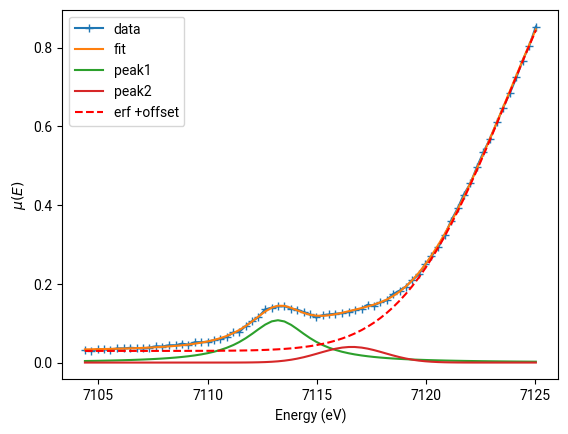

In [ ]:
# read data
dat = read_xdi('Lastbeach_El6_S8900_1p54RHE_Cr_01.xdi')
print("Columns found:", dat.array_labels)
fluo_sum = (dat.fluo01 + dat.fluo02 + dat.fluo03 + dat.fluo04)
xmu = fluo_sum/dat.i0_eh2

# do pre-processing steps, here XAFS pre-edge removal
pre_edge(dat.ebragg, xmu, group=dat)

i1 = np.argmin(np.abs(dat.ebragg - 7104))
i2 = np.argmin(np.abs(dat.ebragg - 7125))
dat.e = dat.ebragg[i1+1:i2+1]
dat.y = dat.norm[i1+1:i2+1]

def make_model(pars, data, components=False):
    ### PEAKS ###
    p1 = pvoigt(data.e, pars.amp1, pars.cen1, pars.wid1, pars.frac1)
    p2 = pvoigt(data.e, pars.amp2, pars.cen2, pars.wid2, pars.frac2)
    ### BKG ###
    e1 = pars.off + pars.erf_amp * erf( pars.erf_wid*(data.e - pars.erf_cen))
    sum = p1 + p2 + e1
    if components:
        return sum, p1, p2,  e1
    return sum


# create a parameter group for the fit:
params = param_group(
    cen1 = param(7113, vary=True, min=7112, max=7114),
    cen2 = param(7116, vary=True , min=7115, max=7118),
    #cen3 = param(6542, vary=True , min=6541.5, max=6543),

    amp1 = param(0.3, vary=True, min=0.01),
    amp2 = param(0.15, vary=True, min=0.01, max=0.15),
    #amp3 = param(0.09, vary=True, min=0.01),

    wid1 = param(0.6, vary=True, min=0.05, max=2),
    wid2 = param(0.4, vary=True, min=0.05, max=2),
    #wid3 = param(0.6, vary=True, min=0.05, max=1),

    frac1 = param(0.8, vary=True , min=0, max=1),
    frac2 = param(0.8, vary=True , min=0, max=1),
    #frac3 = param(0.8, vary=True , min=0, max=1.5),

    off  = param(0.50, vary=True),

    erf_amp = param(0.50, vary=True),
    erf_wid = param(0.50, vary=True),
    erf_cen = param(7125, vary=True, min=7122, max=7128)
    )

def resid(pars, data):
    "fit residual"
    return make_model(pars, data) - data.y


mfit = minimize(resid, params, args=(dat,))

print( fit_report(mfit, show_correl=False))

# now plot results 
final, f1, f2, e1 = make_model(params, dat, components=True)
plt.plot(dat.e, dat.y,  label='data', marker='+')
   

plt.plot(dat.e, final,  label='fit')
#plt.plot(dat.e, (final-dat.y)*10, label='diff (10x)')


plt.plot(dat.e, f1, label='peak1',) # win=2
plt.plot(dat.e, f2, label='peak2',) # win=2
#plt.plot(dat.e, f3, label='peak3',) # win=2
plt.plot(dat.e, e1, label='erf +offset', color='red', linestyle = 'dashed') #, win=2 , style='dashed'
plt.xlabel('Energy (eV)')
plt.ylabel('$\\mu(E)$')
plt.legend()
plt.savefig('S8_Cr_154_PE_sum.png', format='png', dpi=1000)
plt.show()

## ebragg', 'i0_eh2', 'i1_eh2', 'ix_eh2', 'ir_eh2', 'i0_eh1', 'i1_eh1', 'ix_eh1', 'fluo01', 'fluo02', 'fluo03', 'fluo04', 'fluo09', 'fluo10', 'fluo11', 'fluo12', 'fluo13', 'volt1', 'volt2', 'c8', 'c9
#    chi-square         = 0.00106883
#   reduced chi-square = 2.0167e-05




In [ ]:
type( fit_report(mfit, show_correl=False))
report = fit_report(mfit, show_correl=False)

with open('S8_Cr_154_sum.res' , 'w' ) as f:
    f.write(report)